To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **[Unsloth Desktop](https://unsloth.ai/docs/desktop)**, the first desktop app to run and train models. Free and open-source for macOS, Windows and Linux. [GitHub](https://github.com/unslothai/unsloth) • [Download](https://unsloth.ai/download)

<p>
<a href="https://unsloth.ai/docs/desktop"><img src="https://raw.githubusercontent.com/unslothai/notebooks/refs/heads/main/assets/unsloth-qwen3-8.png" width="350" alt="Introducing Unsloth Desktop"></a>
</p>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    !pip install sentencepiece protobuf "datasets==4.3.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate peft trl triton unsloth
    !unsloth install-kernels
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps "transformers @ git+https://github.com/huggingface/transformers@92cd495f2720c064bc78eb2d93e28704c5bce51f" "tokenizers>=0.23.1,<0.24" "safetensors>=0.8.0"
!pip install "huggingface_hub>=1.31.0,<2.0" "sentence-transformers>=6.1.0" torchcodec

### Unsloth

**EmbeddingGemma 2** embeds text, images, audio and video into one 768-dim space. Below are small search demos on Flickr30k, Clotho and MSR-VTT.

In [2]:
from unsloth import FastSentenceTransformer
import torch

model = FastSentenceTransformer.from_pretrained(
    model_name = "unsloth/embeddinggemma-2",
    for_inference = True, # inference only: no LoRA, no training patches
)
print(model)
print("dtype:", next(model.parameters()).dtype)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: mamba_ssm's Triton kernels need compute capability 8.0+ (this GPU is 7.5). Using the PyTorch slow path for Mamba models.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.


Loading weights:   0%|          | 0/1376 [00:00<?, ?it/s]

Unsloth: embedding_gemma2 does not support float16 and this GPU has no bfloat16. Using float32.
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'image': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'audio': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'video': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'message': {'method': 'forward', 'method_output_name': 'last_hidden_state', 'format': 'structured'}}, 'module_output_name': 'token_embeddings', 'architecture': 'EmbeddingGemma2Model'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
dtype: torch.float32


In [3]:
# @title Small display helpers (thumbnails, audio players, video)
import io, base64, html, torch
from IPython.display import display, HTML, Audio, Video
from PIL import Image

def show_images(images, captions = None, size = 160):
    cells = []
    for i, img in enumerate(images):
        buf = io.BytesIO(); img.copy().convert("RGB").resize((size, size)).save(buf, format = "JPEG")
        cap = html.escape(captions[i]) if captions else ""
        cells.append(f'<div style="display:inline-block;margin:4px;width:{size}px;font-size:11px;vertical-align:top">'
                     f'<img src="data:image/jpeg;base64,{base64.b64encode(buf.getvalue()).decode()}"><br>{cap}</div>')
    display(HTML("".join(cells)))

def recall_at_k(similarity, positives, ks = (1, 5, 10)):
    """similarity: [queries, items]; positives[q] = set of correct item indices."""
    ranking = similarity.argsort(dim = 1, descending = True)
    out = {}
    for k in ks:
        top = ranking[:, :k].tolist()
        out[f"R@{k}"] = round(100 * sum(len(set(t) & positives[q]) > 0 for q, t in enumerate(top)) / len(top), 2)
    return out

### 1. Text search
Queries use `prompt_name = "query"`, documents `prompt_name = "document"`.

In [4]:
documents = [
    "The aurora borealis is caused by charged particles from the solar wind colliding with oxygen and nitrogen in the upper atmosphere.",
    "Photosynthesis lets plants turn carbon dioxide and water into sugar using sunlight.",
    "The Great Barrier Reef is the world's largest coral reef system, off the coast of Queensland, Australia.",
    "Mount Everest's summit is 8,849 metres above sea level.",
    "A transformer is a neural network architecture built on self-attention.",
    "Unsloth makes fine-tuning large language models up to 2x faster with less memory.",
]
query = "Why is the sky green and purple near the north pole at night?"

doc_embeddings = model.encode(documents, prompt_name = "document", convert_to_tensor = True)
query_embedding = model.encode(query, prompt_name = "query", convert_to_tensor = True)
scores = model.similarity(query_embedding, doc_embeddings)[0]
for i in scores.argsort(descending = True).tolist():
    print(f"{scores[i]:.3f} | {documents[i]}")

0.715 | The aurora borealis is caused by charged particles from the solar wind colliding with oxygen and nitrogen in the upper atmosphere.
0.557 | Mount Everest's summit is 8,849 metres above sea level.
0.543 | A transformer is a neural network architecture built on self-attention.
0.541 | Photosynthesis lets plants turn carbon dioxide and water into sugar using sunlight.
0.520 | Unsloth makes fine-tuning large language models up to 2x faster with less memory.
0.505 | The Great Barrier Reef is the world's largest coral reef system, off the coast of Queensland, Australia.


Other prompts: `QuestionAnswering`, `FactChecking`, `CodeRetrieval`, `SentenceSimilarity`, `Clustering`, `Classification`. Images, audio and video need no prompt.

In [5]:
for name, prompt in model.prompts.items():
    print(f"{name:26s} -> {prompt!r}")

query                      -> 'task: search result | query: '
document                   -> 'title: none | text: '
BitextMining               -> 'task: search result | query: '
Classification             -> 'task: classification | query: '
Clustering                 -> 'task: clustering | query: '
CodeRetrieval              -> 'task: code retrieval | query: '
Document                   -> 'title: none | text: '
FactChecking               -> 'task: fact checking | query: '
InstructionRetrieval       -> 'task: code retrieval | query: '
MultilabelClassification   -> 'task: classification | query: '
PairClassification         -> 'task: sentence similarity | query: '
QuestionAnswering          -> 'task: question answering | query: '
Reranking                  -> 'task: search result | query: '
Retrieval                  -> 'task: search result | query: '
Retrieval-document         -> 'title: none | text: '
Retrieval-query            -> 'task: search result | query: '
STS                    

### 2. Image search on Flickr30k (1K test)

images_flickr_1k_test.zip: reconstructing file:   0%|          |  0.00B /  141MB            

images_flickr_1k_test.zip: downloading bytes:           |  0.00B            

test_1k_flickr.csv: reconstructing file:   0%|          |  0.00B / 1.13MB            

test_1k_flickr.csv: downloading bytes:           |  0.00B            

1000 images, 5000 captions



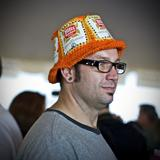
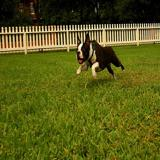
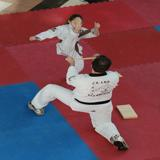
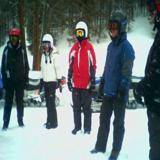
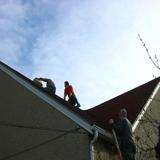
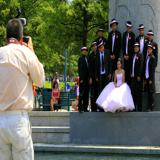

In [6]:
import zipfile, csv, json, os
from huggingface_hub import hf_hub_download

repo = "nlphuji/flickr_1k_test_image_text_retrieval"
zip_path = hf_hub_download(repo, "images_flickr_1k_test.zip", repo_type = "dataset")
csv_path = hf_hub_download(repo, "test_1k_flickr.csv", repo_type = "dataset")

rows = list(csv.DictReader(open(csv_path)))
archive = zipfile.ZipFile(zip_path)
name_to_member = {os.path.basename(n): n for n in archive.namelist() if n.endswith(".jpg")}
flickr_images = [Image.open(archive.open(name_to_member[r["filename"]])).convert("RGB") for r in rows]
flickr_captions, caption_to_image = [], []
for i, r in enumerate(rows):
    for c in json.loads(r["raw"]):
        flickr_captions.append(c); caption_to_image.append(i)
print(len(flickr_images), "images,", len(flickr_captions), "captions")
show_images(flickr_images[:6], [json.loads(r["raw"])[0] for r in rows[:6]])

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedded 1000 images + 5000 captions in 450s



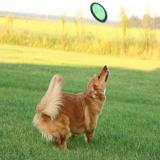
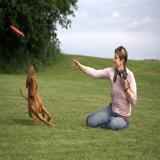
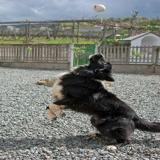
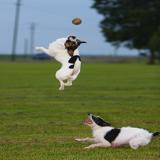
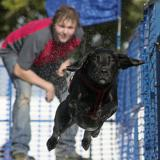


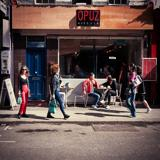
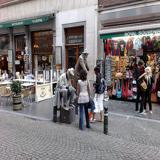
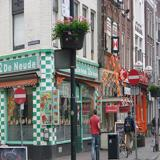
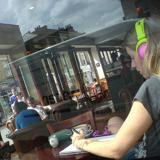
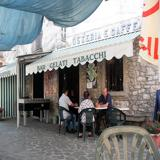

In [7]:
import time
start = time.time()
image_embeddings = model.encode(flickr_images, batch_size = 16, convert_to_tensor = True, show_progress_bar = True)
caption_embeddings = model.encode(flickr_captions, batch_size = 64, convert_to_tensor = True)
print(f"Embedded {len(flickr_images)} images + {len(flickr_captions)} captions in {time.time() - start:.0f}s")

def search_images(text, k = 5):
    q = model.encode(text, convert_to_tensor = True)
    scores = model.similarity(q, image_embeddings)[0]
    top = scores.topk(k)
    show_images([flickr_images[i] for i in top.indices.tolist()], [f"{s:.3f}" for s in top.values.tolist()])

search_images("a dog jumping to catch a frisbee")
search_images("people sitting at a cafe on a busy street")


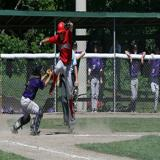
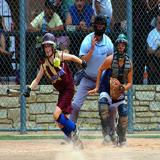
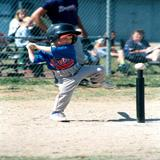
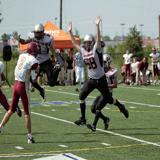
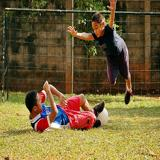

In [8]:
scores = model.similarity(image_embeddings[7:8], image_embeddings)[0]
show_images([flickr_images[i] for i in scores.topk(5).indices.tolist()])

Recall@K:

In [9]:
text_to_image = model.similarity(caption_embeddings, image_embeddings).float().cpu()
t2i = recall_at_k(text_to_image, [{caption_to_image[q]} for q in range(len(flickr_captions))])
image_to_texts = [set(j for j, img in enumerate(caption_to_image) if img == i) for i in range(len(flickr_images))]
i2t = recall_at_k(text_to_image.T, image_to_texts)
print("Flickr30k 1K  text->image:", t2i)
print("Flickr30k 1K  image->text:", i2t)

Flickr30k 1K  text->image: {'R@1': 87.16, 'R@5': 97.58, 'R@10': 98.86}
Flickr30k 1K  image->text: {'R@1': 96.0, 'R@5': 99.9, 'R@10': 99.9}


### 3. Matryoshka
Use `truncate_dim` for 512, 256 or 128 dimensions.

In [10]:
import torch.nn.functional as F
print(f"{'dims':>5s}  {'text->image R@1':>16s}  {'R@5':>6s}")
for dims in [768, 512, 256, 128]:
    q = F.normalize(caption_embeddings[:, :dims].float(), dim = -1)
    d = F.normalize(image_embeddings[:, :dims].float(), dim = -1)
    r = recall_at_k((q @ d.T).cpu(), [{caption_to_image[i]} for i in range(len(flickr_captions))], ks = (1, 5))
    print(f"{dims:5d}  {r['R@1']:16.2f}  {r['R@5']:6.2f}")

small = model.encode(["a dog on the beach"], truncate_dim = 256, normalize_embeddings = True)
print("truncated shape:", small.shape)

 dims   text->image R@1     R@5
  768             87.16   97.58
  512             86.56   97.36
  256             84.94   96.84
  128             74.34   91.86
truncated shape: (1, 256)


### 4. Sound search on Clotho

In [11]:
import soundfile as sf, numpy as np, pyarrow.parquet as pq
clotho_path = hf_hub_download("mteb/Clotho", "data/test-00000-of-00005.parquet", repo_type = "dataset")
clotho = pq.read_table(clotho_path).to_pylist()

os.makedirs("clotho", exist_ok = True)
clips = [] # file paths: sentence-transformers decodes (and resamples) audio files itself
for r in clotho:
    path = f"clotho/{r['index'].rsplit('_', 1)[-1]}.wav"
    open(path, "wb").write(r["audio"]["bytes"]); clips.append(path)
sound_captions, caption_to_clip = [], []
for i, r in enumerate(clotho):
    for c in [c.strip() + "." for c in r["text"].split(". ") if c.strip()]:
        sound_captions.append(c); caption_to_clip.append(i)
print(len(clips), "clips,", len(sound_captions), "captions")

clip_embeddings = model.encode([{"audio": c} for c in clips], batch_size = 8, convert_to_tensor = True, show_progress_bar = True)
sound_caption_embeddings = model.encode(sound_captions, batch_size = 64, convert_to_tensor = True)

def search_sounds(text, k = 2):
    q = model.encode(text, convert_to_tensor = True)
    scores = model.similarity(q, clip_embeddings)[0]
    for s, i in zip(*scores.topk(k)):
        print(f"{s:.3f} | {clotho[i]['text'].split('. ')[0]}")
        display(Audio(filename = clips[i]))

search_sounds("heavy rain falling on a roof")
r = recall_at_k(model.similarity(sound_caption_embeddings, clip_embeddings).float().cpu(),
                [{caption_to_clip[q]} for q in range(len(sound_captions))])
print("Clotho (209 clips) text->audio:", r)

data/test-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  443MB            

data/test-00000-of-00005.parquet: downloading bytes:           |  0.00B            

209 clips, 945 captions


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

0.755 | A child far away shouts as waves roll in from the ocean and crash


0.755 | Water is flowing constantly with occasional bursts of activity


Clotho (209 clips) text->audio: {'R@1': 10.37, 'R@5': 29.95, 'R@10': 44.23}


### 5. Video search on MSR-VTT (first 40 test videos)

In [13]:
from huggingface_hub import HfFileSystem
test_1k = json.load(open(hf_hub_download("friedrichor/MSR-VTT", "msrvtt_test_1k.json", repo_type = "dataset")))[:40]
os.makedirs("msrvtt", exist_ok = True)
with HfFileSystem().open("datasets/friedrichor/MSR-VTT/MSRVTT_Videos.zip", "rb") as f:
    remote = zipfile.ZipFile(f)
    members = {os.path.basename(n): n for n in remote.namelist() if n.endswith(".mp4")}
    for item in test_1k:
        target = f"msrvtt/{item['video']}"
        if not os.path.exists(target):
            open(target, "wb").write(remote.read(members[item["video"]]))
videos = [f"msrvtt/{item['video']}" for item in test_1k]
video_captions = [item["caption"] for item in test_1k]

video_embeddings = model.encode([{"video": v} for v in videos], batch_size = 2, convert_to_tensor = True, show_progress_bar = True)
video_caption_embeddings = model.encode(video_captions, convert_to_tensor = True)
r = recall_at_k(model.similarity(video_caption_embeddings, video_embeddings).float().cpu(), [{i} for i in range(len(videos))], ks = (1, 5))
print("MSR-VTT (first 40 of 1K-A) text->video:", r)

# query = "fish swimming around in an aquarium"
query = "duck swimming around in an aquarium"
best = model.similarity(model.encode(query, convert_to_tensor = True), video_embeddings)[0].argmax().item()
print("Query:", query, "| best match:", videos[best], "| its caption:", video_captions[best])
display(Video(videos[best], embed = True, width = 320))

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

MSR-VTT (first 40 of 1K-A) text->video: {'R@1': 82.5, 'R@5': 97.5}
Query: duck swimming around in an aquarium | best match: msrvtt/video7061.mp4 | its caption: goldfish chase each other around a blue tank to music


In [18]:
query = "music"
best = model.similarity(model.encode(query, convert_to_tensor = True), video_embeddings)[0].argmax().item()
print("Query:", query, "| best match:", videos[best], "| its caption:", video_captions[best])
display(Video(videos[best], embed = True, width = 320))

Query: music | best match: msrvtt/video7150.mp4 | its caption: a picture of the batsman is shown and he is ready for the batting and the audience are watching the show


### 6. Interleaved queries
Use `<|image|>`, `<|audio|>` and `<|video|>` placeholders in the text.

one vector: (768,) norm 1.0



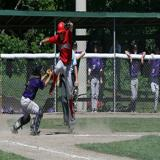
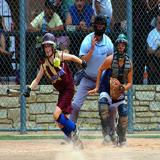
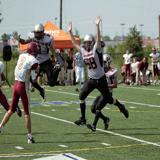
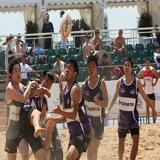
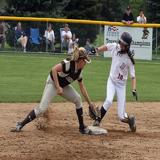

In [19]:
mixed_query = {
    "text": "A photo like <|image|> but at the beach, with a sound like <|audio|>",
    "image": flickr_images[7],
    "audio": clips[0],
}
mixed = model.encode(mixed_query, convert_to_tensor = True)
print("one vector:", tuple(mixed.shape), "norm", round(mixed.norm().item(), 4))
scores = model.similarity(mixed, image_embeddings)[0]
show_images([flickr_images[i] for i in scores.topk(5).indices.tolist()])

### 7. Load only what you need
Text only is 271M parameters instead of 744M.

In [20]:
import gc
del model; gc.collect(); torch.cuda.empty_cache()
variants = {
    "text only":      {"vision_config": None, "audio_config": None},
    "text + vision":  {"audio_config": None},
    "text + audio":   {"vision_config": None},
    "full (omni)":    {},
}
print(f"{'variant':16s} {'params':>10s} {'VRAM (GB)':>10s}")
for name, config_kwargs in variants.items():
    torch.cuda.empty_cache(); base = torch.cuda.memory_allocated()
    m = FastSentenceTransformer.from_pretrained("unsloth/embeddinggemma-2", for_inference = True, config_kwargs = config_kwargs)
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:16s} {params / 1e6:9.1f}M {(torch.cuda.memory_allocated() - base) / 2**30:10.2f}")
    del m; gc.collect(); torch.cuda.empty_cache()

variant              params  VRAM (GB)
Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.


Loading weights:   0%|          | 0/413 [00:00<?, ?it/s]

Unsloth: embedding_gemma2 does not support float16 and this GPU has no bfloat16. Using float32.
text only            271.0M       1.01
Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.


Loading weights:   0%|          | 0/624 [00:00<?, ?it/s]

Unsloth: embedding_gemma2 does not support float16 and this GPU has no bfloat16. Using float32.
text + vision        438.8M       1.63
Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.


Loading weights:   0%|          | 0/1165 [00:00<?, ?it/s]

Unsloth: embedding_gemma2 does not support float16 and this GPU has no bfloat16. Using float32.
text + audio         576.6M       2.15
Unsloth: Not planning a device map; SentenceTransformer moves the assembled model onto a single device. Using `sequential`.


Loading weights:   0%|          | 0/1376 [00:00<?, ?it/s]

Unsloth: embedding_gemma2 does not support float16 and this GPU has no bfloat16. Using float32.
full (omni)          744.4M       2.77


### Next steps
* Fine-tune EmbeddingGemma 2 on your own text pairs: `EmbeddingGemma2_(300M).ipynb`
* Fine-tune image <-> text retrieval: `EmbeddingGemma2_(300M)-Image_Text.ipynb`
* Fine-tune audio <-> text retrieval: `EmbeddingGemma2_(300M)-Audio.ipynb`
And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)
</div>